# v2 rebuilt correctly

v2 is v1 plus `in_nitro`: a binary flag for whether a pitch falls inside the
convex hull of the locations where that hitter produced his top 5% exit
velocities — an attempt to tell the model where *this* hitter does damage.

This is v2 **as designed**, with its defects corrected and nothing added — the
zone stays a binary convex hull at the top-5% threshold with a 60-BIP minimum,
built from every prior season, and `in_nitro` goes to both action models. Two
things are fixed:

| defect | fix |
|---|---|
| The hull was built from the **same season** it scored, so `in_nitro` partly encoded the outcome it predicted, and on held-out seasons it used the future. | Built from **prior seasons only**. |
| `add_nitro_zone` inner-merged on `batter`, so a hitter with no hull vanished from the data entirely. | Left join; no hull → `False`. |

Learner, hyperparameters and folds are held at v1's, so the only thing
changing between the two rows below is the feature.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src import data as D, features as F, evaluate as E
from src.baselines import V1_FEATURES

pd.set_option('display.width', 130); sns.set_theme(style='whitegrid')
PALETTE = ['#FFB000', '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#3D1EB2']
SEASONS = range(2021, 2026)          # 2026 is kept out of model selection; not loaded here
FOLDS = E.PERSONALIZED_FOLDS
V2_FEATURES = V1_FEATURES + ['in_nitro']
print(V2_FEATURES)

['plate_x_mid', 'plate_z_mid', 'count', 'in_nitro']


In [2]:
df = D.drop_pitchers_batting(D.load_seasons(SEASONS, verbose=False))
df = D.add_zone_frame(df.dropna(subset=['plate_x_mid', 'plate_z_mid']))
print(f'{len(df):,} rows')

3,517,807 rows


## Building the nitro zone without leakage

Each season's hulls come from seasons strictly before it, asserted in
`season_in_nitro()`. 2021 has no prior season, so it cannot be scored; it
serves only as prior data.

In [3]:
v2df, coverage = F.season_in_nitro(df)
print(f'rows {len(df):,} -> {len(v2df):,}  (2021 unavailable: {(df.season == 2021).sum():,})')
coverage.round(3)

rows 3,517,807 -> 2,827,989  (2021 unavailable: 689,818)


,prior_seasons,hulls,qualified,qualified_with_hull,coverage,in_nitro_rate
season,,,,,,
2022,2021-2021,472,435,345,0.793,0.145
2023,2021-2022,590,432,356,0.824,0.203
2024,2021-2023,696,425,372,0.875,0.231
2025,2021-2024,777,419,358,0.854,0.251


Coverage runs 79–88% of qualified hitters, worst in 2022 whose only prior is
2021. The rest score `in_nitro = False` on every pitch — under v2's inner merge
they would have been deleted from the data entirely, which at this scale is a
large and non-random loss.

Note `in_nitro_rate` climbing from 0.145 to 0.251. Come back to that below.

## Fit and score, on the personalized folds

A personalized variant needs a prior season to build its hitter feature from,
so 2021 cannot be training data. Both rows use the same folds, so the
comparison varies only the feature:

| fold | train | held out |
|---|---|---|
| 1 | 2022 | 2023 |
| 2 | 2022–23 | 2024 |
| 3 | 2022–24 | 2025 |

v1 here is therefore not the v1 notebook's row, which trains from 2021.

In [4]:
run1 = E.run_folds(v2df, V1_FEATURES, FOLDS)
run2 = E.run_folds(v2df, V2_FEATURES, FOLDS, swing_only=False)   # as designed: both models
r1 = E.harness(run1, 'v1 (personalized folds)', value_col='y_pred')
r2 = E.harness(run2, 'v2', value_col='y_pred')
pd.DataFrame([r1['summary'], r2['summary']]).set_index('variant').T

variant,v1 (personalized folds),v2
chase | zone_swing,-0.883,-0.792
zone_swing | chase,0.669,0.535
split-half r,0.757,0.792
YoY R2 (mean),0.526,0.535
Zone% |r|,0.081,0.031
next-season r (partial),0.137,0.135
swing bin err / count-only,0.0210 / 0.0365,0.0206 / 0.0365
swing signal recovered,0.827,0.844
swing calib slope,1.279,1.277
take bin err / count-only,0.0032 / 0.0363,0.0032 / 0.0363


In [5]:
# Year over year, per held-out pair.
pd.concat([r1['yoy'].r2.rename('v1'), r2['yoy'].r2.rename('v2')], axis=1).round(3)

,v1,v2
pair,,
2023->2024,0.549,0.558
2024->2025,0.502,0.513


## Player metric and reliability

Both variants side by side throughout. The summary row reports means; the
per-season detail is where a difference either holds up across the board or
turns out to rest on one season.

In [6]:
qual = pd.concat([r1['scores'].groupby('season').size().rename('v1'),
                  r2['scores'].groupby('season').size().rename('v2')], axis=1)
print('qualified hitters (>=500 pitches) per held-out season:')
qual

qualified hitters (>=500 pitches) per held-out season:


,v1,v2
season,,
2023,432,432
2024,425,425
2025,419,419


In [7]:
# Split-half: odd/even plate appearances within a season, Spearman-Brown
# corrected. Cleaner than year-over-year, since real skill change is held fixed.
pd.concat([r1['split_half'].r_spearman_brown.rename('v1'),
           r2['split_half'].r_spearman_brown.rename('v2')], axis=1).round(3)

,v1,v2
season,,
2023,0.789,0.817
2024,0.722,0.757
2025,0.760,0.802


## Validity

Reliability only says the metric is repeatable. These ask whether it is
repeatable *about the right thing*: tracking both halves of a swing decision,
not contaminated by the pitches a hitter happened to see, and carrying
information about what he does next.

In [8]:
pd.concat([r1['construct'].assign(variant='v1'), r2['construct'].assign(variant='v2')]).set_index('variant').round(3)

,hitters,chase (raw),zone_swing (raw),chase | zone_swing,zone_swing | chase,"corr(chase, zone_swing)"
variant,,,,,,
v1,1276,-0.776,-0.027,-0.883,0.669,0.505
v2,1276,-0.690,-0.014,-0.792,0.535,0.505


In [9]:
# Zone%: does the metric mostly track the share of pitches a hitter sees in the
# strike zone? A metric explained by opportunity is not measuring decisions.
pd.concat([r1['zone_pct']['r'].rename('v1 r'),
           r2['zone_pct']['r'].rename('v2 r'),
           r1['zone_pct']['variance_explained_%'].rename('v1 var%'),
           r2['zone_pct']['variance_explained_%'].rename('v2 var%')], axis=1).round(3)

,v1 r,v2 r,v1 var%,v2 var%
season,,,,
2023,0.084,0.036,0.711,0.129
2024,0.101,0.052,1.015,0.265
2025,0.058,-0.007,0.331,0.005


In [10]:
# Does season-t decision value predict season-t+1 production, once season-t
# production is controlled for?
pd.concat([r1['predictive'].r_raw.rename('v1 raw'), r2['predictive'].r_raw.rename('v2 raw'),
           r1['predictive'].r_partial.rename('v1 partial'),
           r2['predictive'].r_partial.rename('v2 partial')], axis=1).round(3)

,v1 raw,v2 raw,v1 partial,v2 partial
pair,,,,
2023->2024,0.291,0.316,0.152,0.170
2024->2025,0.275,0.281,0.122,0.101


**The de-leaked hull trades construct validity for reliability.** Split-half
reliability improves in all three held-out seasons, by 0.03–0.04; YoY R² edges
up (0.535 against 0.526) and pitch-mix contamination falls (Zone% |r| 0.031
against 0.081). But **construct validity degrades**: −0.792 / +0.535 against
v1's −0.883 / +0.669 on the same folds.

That combination is the signature of a hitter-specific feature pulling the
score away from "did he decide well" and toward "is he a good hitter". v2
scores the value of the action taken, so a hitter whose hull covers more of the
zone gets a higher `Q_swing` on his swings, and a higher score, independent of
his judgement.

Next-season validity does not settle it either way: v2 wins 2023→24 (0.170
against 0.152) and loses 2024→25 (0.101 against 0.122), for means of 0.135 and
0.137.

## But what is `in_nitro` actually measuring?

In [11]:
# Share of model gain by feature, fold 3 (train 2022-24).
m2 = run2.models[2025]
for name, booster in (('take', m2.take), ('swing', m2.swing)):
    imp = booster.get_score(importance_type='gain'); tot = sum(imp.values())
    print(f'{name:6s} ' + '  '.join(f'{k} {v/tot:.1%}' for k, v in sorted(imp.items(), key=lambda x: -x[1])))

take   in_nitro 79.7%  count 10.1%  plate_z_mid 5.5%  plate_x_mid 4.7%
swing  in_nitro 89.5%  count 5.6%  plate_z_mid 3.4%  plate_x_mid 1.6%


In [12]:
# Contact quality cannot change what an umpire calls, so in_nitro should do
# nothing for the take model. Held out, on both the pitch level and bin means.
for lbl, r in (('without in_nitro', r1), ('with in_nitro', r2)):
    s, c = r['sub_models'], r['calibration']
    print(f'{lbl:18s} take RMSE {s.loc["take","rmse"]:.5f}   take bin err {c["take"].err.mean():.5f}'
          f'   swing bin err {c["swing"].err.mean():.5f}   swing slope {c["swing"].slope.mean():.3f}')

without in_nitro   take RMSE 0.04361   take bin err 0.00318   swing bin err 0.02104   swing slope 1.279
with in_nitro      take RMSE 0.04368   take bin err 0.00318   swing bin err 0.02060   swing slope 1.277


In [13]:
v2df['in_zone'] = D.in_rulebook_zone(v2df, ball_edge=True)
print(f'P(in_nitro | in zone)     = {v2df.loc[v2df.in_zone, "in_nitro"].mean():.3f}')
print(f'P(in_nitro | out of zone) = {v2df.loc[~v2df.in_zone, "in_nitro"].mean():.3f}')
print(f'correlation(in_nitro, in_zone) = {np.corrcoef(v2df.in_nitro, v2df.in_zone)[0,1]:.3f}')
print(f'share of in_nitro pitches that are in the zone = {v2df.loc[v2df.in_nitro, "in_zone"].mean():.3f}')

P(in_nitro | in zone)     = 0.437
P(in_nitro | out of zone) = 0.019
correlation(in_nitro, in_zone) = 0.512
share of in_nitro pitches that are in the zone = 0.949


In [14]:
# If in_nitro were purely location it would be constant across hitters within a
# location cell. How much does it actually vary between hitters?
g = v2df[v2df.season == 2025]
cell = g.assign(cx=pd.cut(g.plate_x_mid, np.arange(-1.2, 1.3, 0.3), labels=False),
                cz=pd.cut(g.plate_z_mid, np.arange(1.2, 4.2, 0.3), labels=False)).dropna(subset=['cx', 'cz'])
per = cell.groupby(['cx', 'cz', 'batter'], observed=True).in_nitro.mean()
spread = per.groupby(level=[0, 1]).agg(['mean', 'std', 'size']).query('size >= 100')
print(f'between-hitter std of in_nitro within a location cell: median {spread["std"].median():.3f}')
print(f'cell means range {spread["mean"].min():.2f} .. {spread["mean"].max():.2f}')

between-hitter std of in_nitro within a location cell: median 0.221
cell means range 0.00 .. 0.70


Text(0.5, 1.02, 'The nitro zone grows as prior history accumulates')

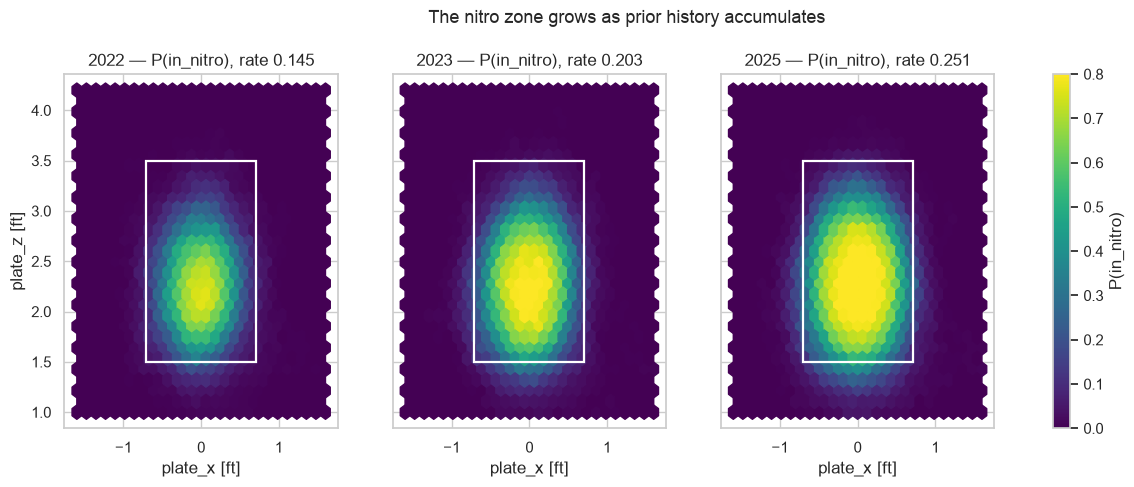

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for a, season in zip(ax, [2022, 2023, 2025]):
    g = v2df[v2df.season == season]
    hb = a.hexbin(g.plate_x_mid, g.plate_z_mid, C=g.in_nitro.astype(float), gridsize=26,
                  extent=[-1.6, 1.6, 1.0, 4.2], cmap='viridis', vmin=0, vmax=0.8)
    a.add_patch(plt.Rectangle((-0.708, 1.5), 1.416, 2.0, fill=False, color='w', lw=1.6))
    a.set_title(f'{season} — P(in_nitro), rate {g.in_nitro.mean():.3f}')
    a.set_xlabel('plate_x [ft]')
ax[0].set_ylabel('plate_z [ft]')
fig.colorbar(hb, ax=ax, label='P(in_nitro)')
fig.suptitle('The nitro zone grows as prior history accumulates', y=1.02, fontsize=13)

## Sanity check

In [16]:
scores2 = r2['scores']
try:
    from pybaseball import playerid_reverse_lookup
    s25 = scores2[scores2.season == 2025].copy()
    nm = playerid_reverse_lookup(s25.batter.tolist())
    nm['name'] = (nm.name_first + ' ' + nm.name_last).str.title()
    s25 = s25.merge(nm[['key_mlbam', 'name']], left_on='batter', right_on='key_mlbam')
    print('TOP 10, 2025'); display(s25.nlargest(10, 'decision_value')[['name','pitches','decision_value']].round(1))
    print('BOTTOM 10, 2025'); display(s25.nsmallest(10, 'decision_value')[['name','pitches','decision_value']].round(1))
except Exception as exc:
    print(f'name lookup unavailable ({exc})'); display(scores2[scores2.season == 2025].nlargest(10, 'decision_value'))

Gathering player lookup table. This may take a moment.


TOP 10, 2025


,name,pitches,decision_value
154,Kyle Tucker,2275,128.0
139,Ronald Acuña,1741,127.1
31,Max Muncy,1603,125.0
116,Gleyber Torres,2652,124.1
180,Juan Soto,2968,122.6
20,George Springer,2305,122.1
178,Fernando Tatís,2636,121.8
19,Marcus Semien,2075,120.7
111,Rafael Devers,3060,120.6
107,Jeff Mcneil,1718,119.9


BOTTOM 10, 2025


,name,pitches,decision_value
416,Hyeseong Kim,660,71.2
296,Jhonkensy Noel,563,71.6
257,Denzel Clarke,631,71.7
377,Yanquiel Fernández,608,76.5
268,Lenyn Sosa,2056,76.8
47,Javier Báez,1543,77.4
150,Brandon Lockridge,578,77.4
418,Ben Williamson,1216,77.7
0,Martín Maldonado,569,78.1
162,Jake Mangum,1435,78.4


## Findings

All figures are held out, on the personalized folds, with v1 refit on the same
folds so only the feature differs.

**The de-leaked hull trades construct validity for reliability.** The leak was
what made the original design fail. Built from prior seasons only, the feature
raises split-half reliability in every held-out season and cuts pitch-mix
contamination, but construct validity falls from −0.883 / +0.669 to −0.792 /
+0.535, and next-season validity is unchanged. A hitter-specific feature makes
the score partly a measure of the hitter rather than of his decisions.

**`in_nitro` is mostly a location proxy.** 95% of the pitches it flags are in
the strike zone, and it correlates 0.51 with zone membership. That is why it
takes 80% of the take model's gain and 90% of the swing model's while barely
moving either: the swing model's held-out bin-mean error goes 0.0210 → 0.0206
and its calibration slope does not change. The tree uses the flag as a cheap
"middle of the zone" split, substituting for work `plate_x_mid`/`plate_z_mid`
were already doing. Gain here measures redundancy, not contribution.

It is not *only* location — the between-hitter standard deviation within a
location cell is 0.221, and cell means span 0.00 to 0.70 — so genuine
personalization is in there. It is a small part of what the feature carries.

**It adds nothing to the take model, as predicted.** Held-out take RMSE goes
0.04361 → 0.04368 and the take model's bin-mean error is unchanged at 0.00318.
Contact quality cannot change what an umpire calls. Routing the feature to the
swing model only is a design change rather than a correction, so it belongs to
v3.

**The prior-season fix introduces drift.** Built from every prior season, the
hull grows with accumulated history: the flag fires on 14.5% of pitches in 2022
and 25.1% in 2025. The same hitter with the same true hot zone gets a larger
region in later seasons — a defect of the correction itself, which needs a
fixed prior window.

**Net:** v2 is a usable baseline and the personalization idea survives. What
has to change is the *estimator* — a binary hull over the top 5% of one sample,
drifting with history and largely redundant with location.

In [17]:
pd.DataFrame([r1['summary'], r2['summary']]).set_index('variant')

,chase | zone_swing,zone_swing | chase,split-half r,YoY R2 (mean),Zone% |r|,next-season r (partial),swing bin err / count-only,swing signal recovered,swing calib slope,take bin err / count-only,take signal recovered,take calib slope
variant,,,,,,,,,,,,
v1 (personalized folds),-0.883,0.669,0.757,0.526,0.081,0.137,0.0210 / 0.0365,0.827,1.279,0.0032 / 0.0363,0.993,1.019
v2,-0.792,0.535,0.792,0.535,0.031,0.135,0.0206 / 0.0365,0.844,1.277,0.0032 / 0.0363,0.993,1.020
